In [324]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import sys
from scipy.signal import find_peaks


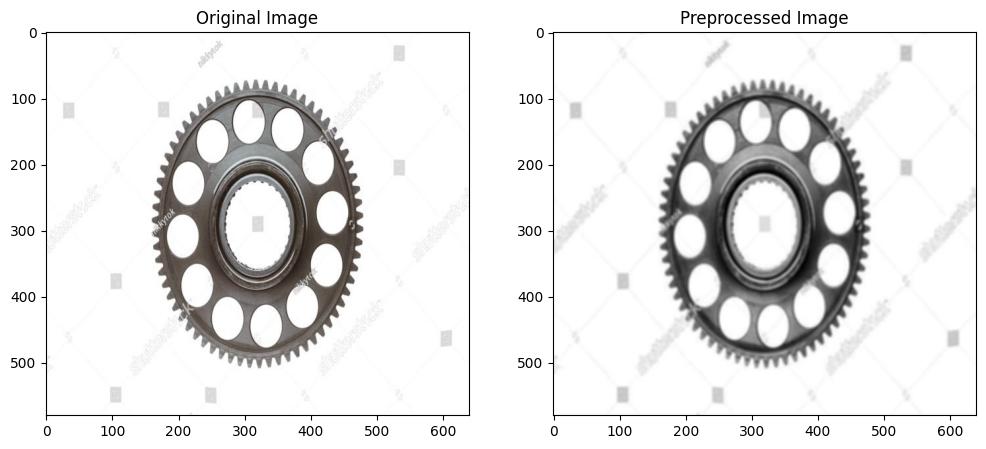

In [325]:
## Image Preprocessing 

# 1. Grayscale Conversion
img = cv2.imread('./data/train/train_6.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. CLAHE Histogram Equalization
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
equalized = clahe.apply(gray)

# 3. Gaussian Blurring
sigma = 5.0
blurred = cv2.GaussianBlur(equalized, (5, 5), sigma)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.title('Preprocessed Image')
plt.imshow(blurred, cmap='gray')

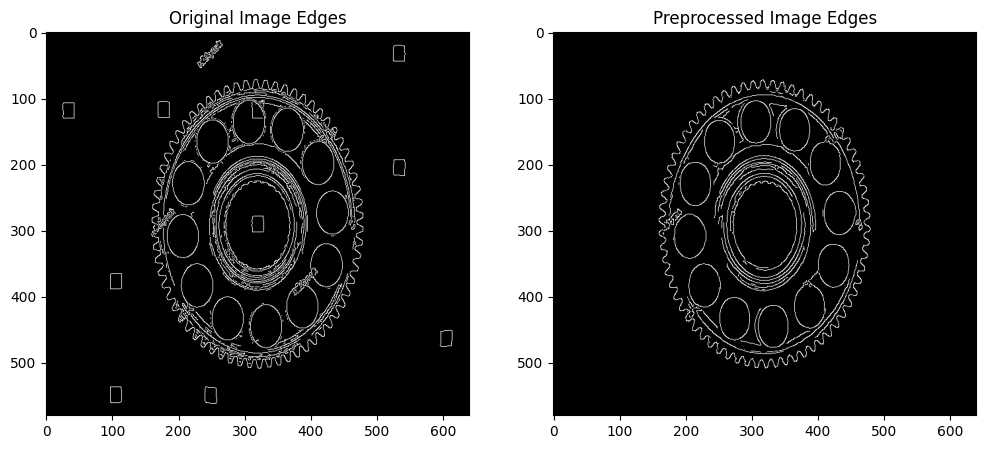

In [326]:
# Edge Detection
original_edges = cv2.Canny(gray, 50, 150)
processed_edges = cv2.Canny(blurred, 50, 150)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image Edges')
plt.imshow(original_edges, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Preprocessed Image Edges')
plt.imshow(processed_edges, cmap='gray')
plt.show()

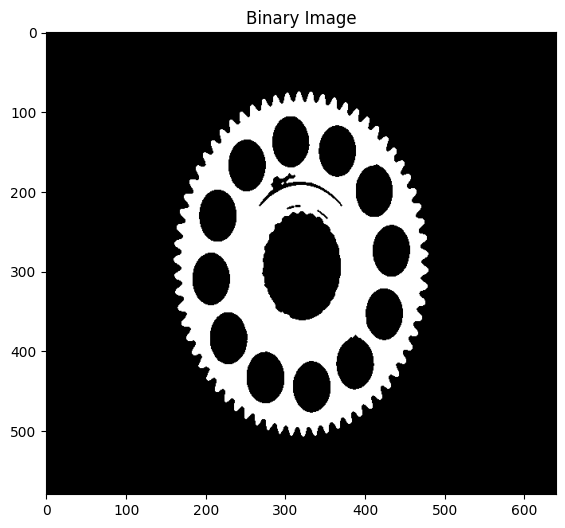

In [327]:
# Binarize and fill the image
from numpy.ma import filled


_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# invert the image if the background is not black (i.e. if the pixel at (1,1) is white)
if binary[1, 1] == 255:
    binary = cv2.bitwise_not(binary)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

# Closing: fills small holes/gaps inside the gear body
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

# Opening: removes small isolated blobs outside the gear
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)


# show results
plt.figure(figsize=(12, 6))
plt.title('Binary Image')
plt.imshow(binary, cmap='gray')
plt.show()


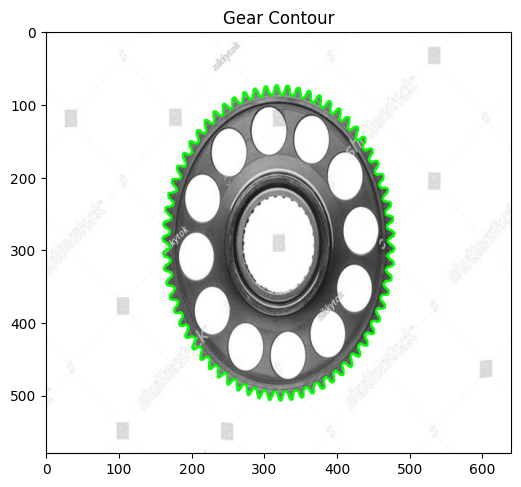

In [328]:
contours, hierarchy = cv2.findContours(
    binary, # binarized and filled image of the gear      
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

gear_contour = max(contours, key=cv2.contourArea)

# show the contour
debug = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)  
cv2.drawContours(debug, [gear_contour], -1, (0, 255, 0), 2)  # green contour
plt.figure(figsize=(6, 6))
plt.title('Gear Contour')
plt.imshow(debug)
plt.show()

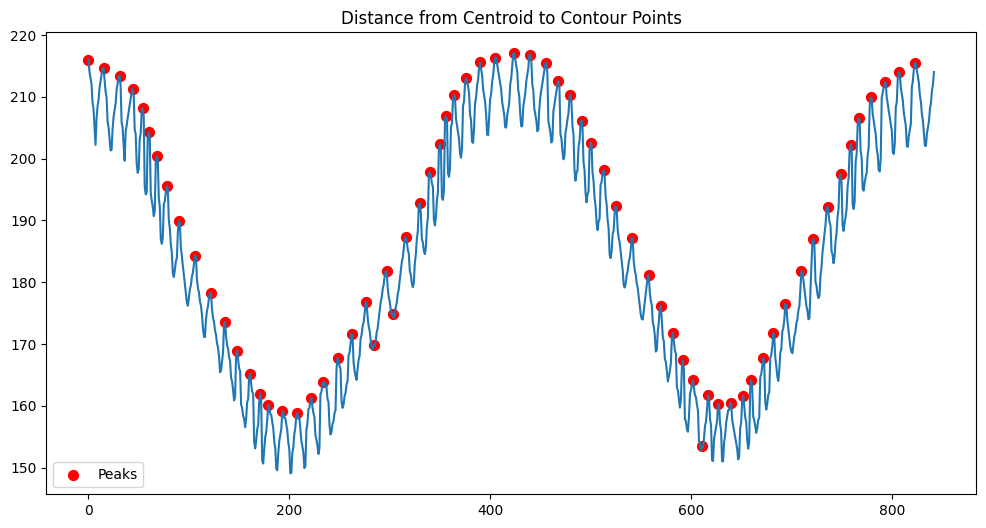

In [331]:
M  = cv2.moments(gear_contour)
cx = int(M['m10'] / M['m00'])
cy = int(M['m01'] / M['m00'])

# Compute all distances from centroid to every contour point
dists = np.array([np.linalg.norm(p[0] - [cx, cy]) for p in gear_contour])
peaks = find_peaks(dists, distance=5)  # distance=10 to avoid close peaks

# add the first peak corrisponding to the first point of the contour if it's not already included

first_peak = peaks[0][0]
last_peak = peaks[0][-1]

if first_peak in range(1, 5) or last_peak in range(len(gear_contour) - 5, len(gear_contour) - 1):
    pass # the first peak is already included in the first or last points
else:
    peaks = (np.insert(peaks[0], 0, 0),)  # add 0 at the beginning of the peaks
    


# clear peaks removing the ones that are included bewteen two higher peaks
peak_smoothing = 1.2
final_peaks = []
for i in range(len(peaks[0])):
    if i == 0 or i == len(peaks[0]) - 1:
        final_peaks.append(peaks[0][i])
    else:
        prev_peak = peaks[0][i - 1]
        next_peak = peaks[0][i + 1]
        if dists[peaks[0][i]] * peak_smoothing < dists[prev_peak]  and dists[peaks[0][i]] * peak_smoothing < dists[next_peak]:
            continue  # skip this peak
        else:
            final_peaks.append(peaks[0][i])

# plot the distances with peaks
plt.figure(figsize=(12, 6))
plt.title('Distance from Centroid to Contour Points')
plt.plot(dists)
plt.scatter(final_peaks, dists[final_peaks], color='red', s=50, label='Peaks')
plt.legend()
plt.show()




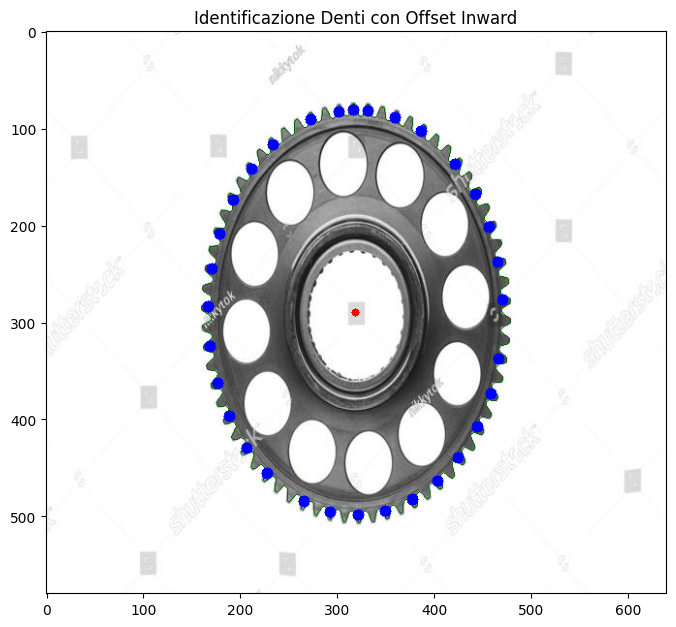

In [330]:
# Array per salvare le coordinate (x, y) dei punti finali sui denti
teeth_points = []

# Quanti pixel vogliamo spostarci dalla punta estrema verso l'interno del dente?
# Regola questo valore in base alla risoluzione della tua immagine e alla dimensione dei denti
offset_inside = 8

for peak_idx in final_peaks:
    # 1. Recupera le coordinate (x, y) della punta esatta dal contorno
    # Ricorda che i contorni di cv2 hanno shape (N, 1, 2)
    tip_x, tip_y = gear_contour[peak_idx][0]
    
    # 2. Calcola il vettore che punta dalla punta del dente verso il baricentro
    dir_x = cx - tip_x
    dir_y = cy - tip_y
    
    # 3. Normalizza il vettore (rendi la sua lunghezza uguale a 1)
    length = np.hypot(dir_x, dir_y) # np.hypot è più rapido per la norma euclidea 2D
    
    if length > 0:
        dir_x_norm = dir_x / length
        dir_y_norm = dir_y / length
        
        # 4. Calcola le nuove coordinate traslate verso l'interno
        final_x = int(tip_x + (dir_x_norm * offset_inside))
        final_y = int(tip_y + (dir_y_norm * offset_inside))
        
        teeth_points.append((final_x, final_y))


# --- VISUALIZZAZIONE FINALE ---
# Usiamo l'immagine a colori per vedere bene i punti
result_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR) 

# Disegniamo il contorno in verde scuro
cv2.drawContours(result_img, [gear_contour], -1, (0, 100, 0), 1)

# Disegniamo il baricentro in blu
cv2.circle(result_img, (cx, cy), 4, (255, 0, 0), -1)

# Disegniamo i punti definitivi dei denti in rosso
for pt in teeth_points:
    cv2.circle(result_img, pt, 6, (0, 0, 255), -1)

plt.figure(figsize=(8, 8))
plt.title('Identificazione Denti con Offset Inward')
plt.imshow(result_img)
plt.show()